# Taller de Laboratorios de Machine Learning y Deep Learning 
Valor total: 30 puntos 
Este taller busca que los estudiantes fortalezcan sus habilidades prácticas en Machine Learning 
(ML) y Deep Learning (DL) mediante laboratorios guiados y desafiantes. Cada laboratorio tiene un 
enfoque diferente: procesamiento de texto, visión por computadora, modelos en la nube, y redes 
neuronales con Tensor Flow.

## **Enunciado B — Red Neuronal (MLP con Keras)** 
Dataset: el mismo de A (para comparar). 
Objetivo: Entrenar una red neuronal densa (MLP) con Keras/TensorFlow. 
Entrega (obligatoria): 
1. Estandarización de variables numéricas con StandardScaler (ajustado solo con train). 
2. Arquitectura sugerida (puedes ajustar): 
○ Input → Dense(64, ReLU) → Dropout(0.2) → Dense(32, ReLU) → Dense(1, Sigmoid) 
3. Entrenamiento con EarlyStopping (monitor val_auc, patience=10, 
restore_best_weights=True) y validation_split=0.2. 
4. Métricas en test (mismas que en A): Accuracy, Precision, Recall, F1, AUC-ROC y Matriz de 
confusión. 
5. Breve análisis (2–4 líneas) comparando con Random Forest.

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Loading dataset
cancer = load_breast_cancer()
X = cancer.data      #Separación de variables predictoras
y = cancer.target    #Variable a predecir

#Exploring dataset
df = pd.DataFrame(X, columns=cancer.feature_names)
df['target'] = y

print('Shape del dataset: ', df.shape)
df.head()

Shape del dataset:  (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Estadisticas descriptivas del dataset: 
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0

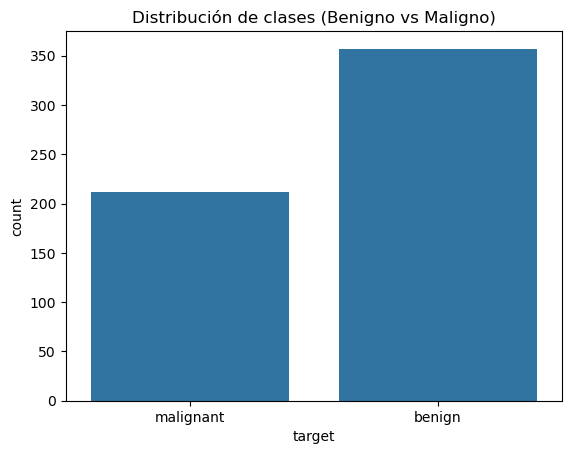

Proporción de clases:
 target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


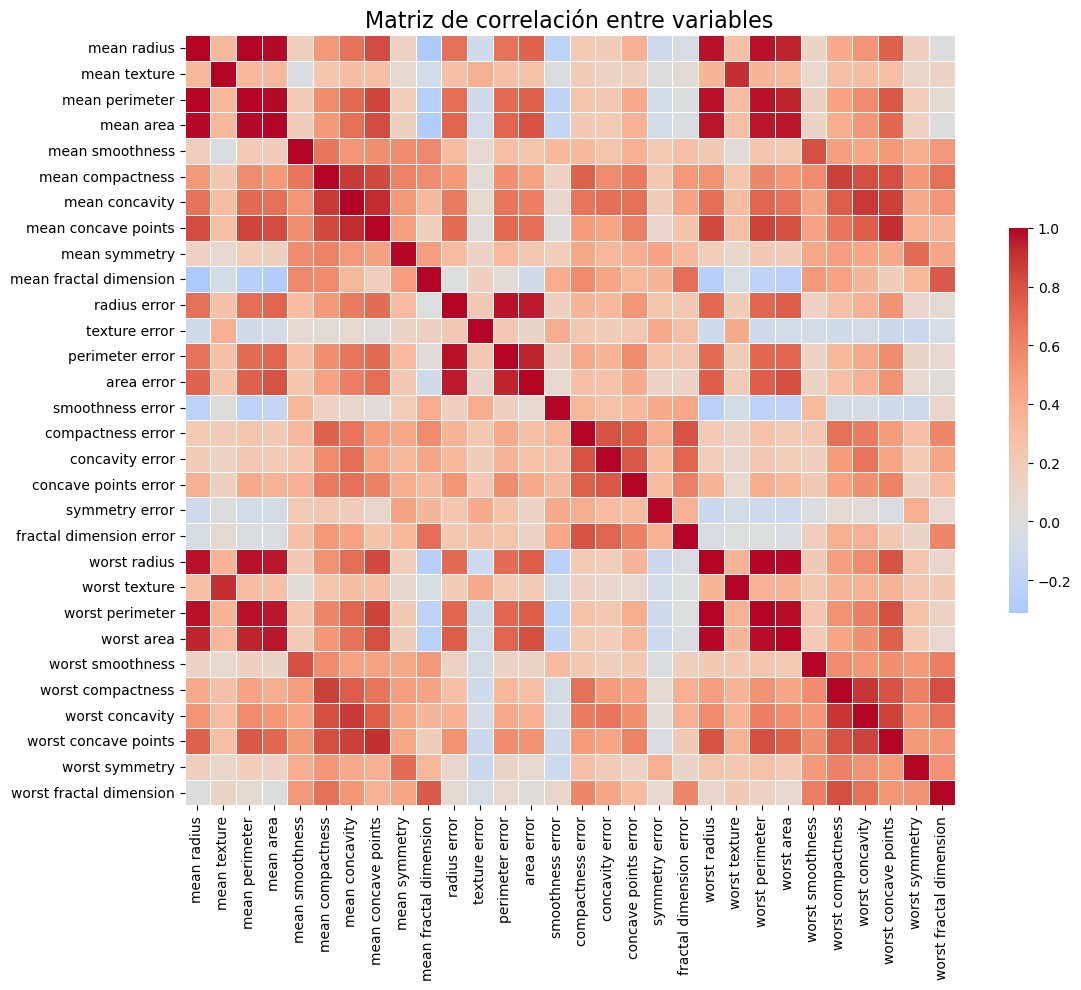

In [2]:
print('Estadisticas descriptivas del dataset: \n', df.describe())
print('Información general del dataset: \n', df.info())

# Distribución de clases (benigno - Maligno)
sns.countplot(x='target', data=df)
plt.xticks([0,1], cancer.target_names)
plt.title("Distribución de clases (Benigno vs Maligno)")
plt.show()

print("Proporción de clases:\n", df['target'].value_counts(normalize=True))

# Matriz de correlación entre variables predictoras
plt.figure(figsize=(14,10))
corr = df.drop('target', axis=1).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink": .5})
plt.title("Matriz de correlación entre variables", fontsize=16)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 455
Test size: 114
